# Importing Libraries

In [1]:
import pandas as pd, numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from scipy.sparse import hstack
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer,PorterStemmer
from nltk.corpus import stopwords
import re
import matplotlib.pyplot as plt
import seaborn as sns
import string
import warnings
warnings.filterwarnings('ignore')

# Loading dataset

In [2]:
train2 = pd.read_csv("/kaggle/input/jigsaw-multilingual-toxic-comment-classification/jigsaw-unintended-bias-train.csv")
train2.toxic = train2.toxic.round().astype(int)
valid1 = pd.read_csv('/kaggle/input/jigsaw-multilingual-toxic-comment-classification/validation.csv')
test = pd.read_csv('/kaggle/input/jigsaw-multilingual-toxic-comment-classification/test.csv')
subm = pd.read_csv('/kaggle/input/jigsaw-multilingual-toxic-comment-classification/sample_submission.csv')

In [3]:
train2=train2[:500000] # as this a too large dataset

In [4]:
train = pd.concat([train2[['comment_text', 'toxic']].query('toxic==1'),
    train2[['comment_text', 'toxic']].query('toxic==0'),valid1[['comment_text', 'toxic']]]).reset_index(drop=True)

In [5]:
train.head(5)

,comment_text,toxic
0,haha you guys are a bunch of losers.,1
1,ur a sh*tty comment.,1
2,It's ridiculous that these guys are being call...,1
3,Yet call out all Muslims for the acts of a few...,1
4,This bitch is nuts. Who would read a book by a...,1


In [6]:
test.head(5)

,id,content,lang
0,0,Doctor Who adlı viki başlığına 12. doctor olar...,tr
1,1,"Вполне возможно, но я пока не вижу необходимо...",ru
2,2,"Quindi tu sei uno di quelli conservativi , ...",it
3,3,Malesef gerçekleştirilmedi ancak şöyle bir şey...,tr
4,4,:Resim:Seldabagcan.jpg resminde kaynak sorunu ...,tr


In [7]:
train['comment_text'][0]

'haha you guys are a bunch of losers.'

In [8]:
test['content'][0]

'Doctor Who adlı viki başlığına 12. doctor olarak bir viki yazarı kendi adını eklemiştir. Şahsen düzelttim. Onaylarsanız sevinirim. Occipital '

In [9]:
lens = train.comment_text.str.len()
lens.mean(), lens.std(), lens.max()

(306.78215354330706, 276.3908289401696, 1906)

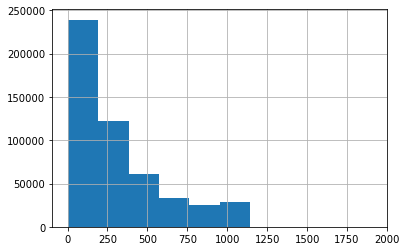

In [10]:
lens.hist();

In [11]:
lens = test.content.str.len()
lens.mean(), lens.std(), lens.max()

(378.2348617814831, 278.9841534749254, 7794)

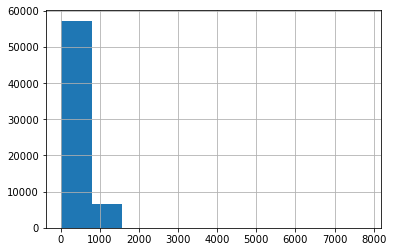

In [12]:
lens.hist()

In [13]:
len(train),len(test)

(508000, 63812)

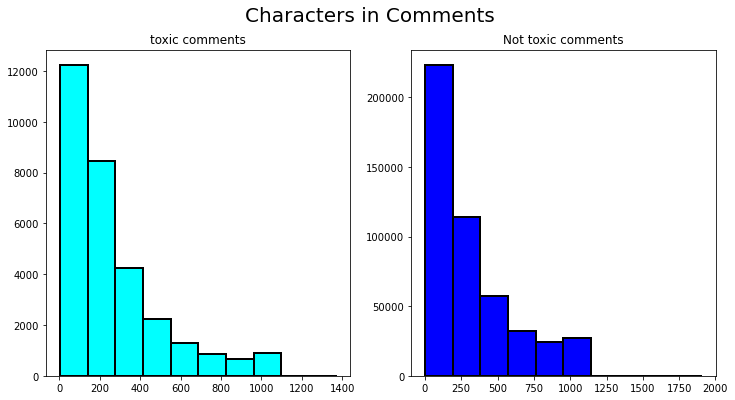

In [14]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,6))
comment_len=train[train['toxic']==1]['comment_text'].str.len()
ax1.hist(comment_len,color='cyan',linewidth=2,edgecolor='k')
ax1.set_title('toxic comments')
comment_len=train[train['toxic']==0]['comment_text'].str.len()
ax2.hist(comment_len,color='blue',linewidth=2,edgecolor='k')
ax2.set_title('Not toxic comments')
fig.suptitle('Characters in Comments',fontsize=20)

plt.show()

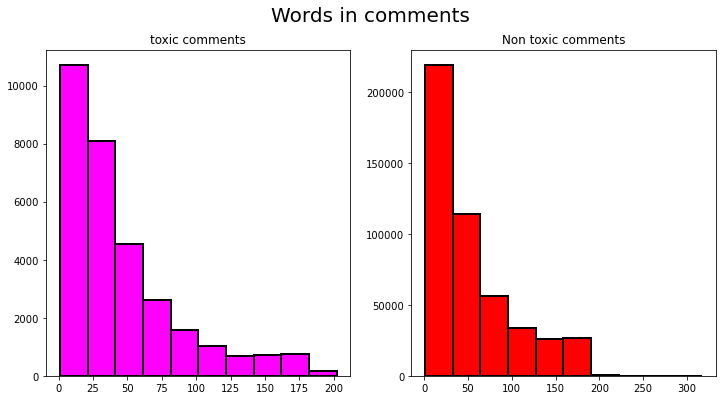

In [15]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,6))
comment_words=train[train['toxic']==1]['comment_text'].str.split().map(lambda x: len(x))
ax1.hist(comment_words,color='magenta',linewidth=2,edgecolor='k')
ax1.set_title('toxic comments')
comment_words=train[train['toxic']==0]['comment_text'].str.split().map(lambda x: len(x))
ax2.hist(comment_words,color='red',linewidth=2,edgecolor='k')
ax2.set_title('Non toxic comments')
fig.suptitle('Words in comments',fontsize=20)
plt.show()

In [16]:
label_cols = ['toxic']

train.describe()

,toxic
count,508000.000000
mean,0.060783
std,0.238933
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [17]:
train['comment_text'].fillna("unknown", inplace=True)
test['content'].fillna("unknown", inplace=True)

# Text Preprocessing

In [18]:
def lower(words):
    return words.lower()
train['comment_text']=train['comment_text'].apply(lambda x:lower(x))
def remove_numbers(words):
    return re.sub(r'\d+','',words)
train['comment_text']=train['comment_text'].apply(lambda x: remove_numbers(x))
def remove_punctuation(words):
    table=str.maketrans('','',string.punctuation)
    return words.translate(table)
train['comment_text']=train['comment_text'].apply(lambda x: remove_punctuation(x))
train['comment_text']=train['comment_text'].apply(lambda x:word_tokenize(x))
def remove_stopwords(words):
    stop_words=set(stopwords.words('english'))
    return [word for word in words if word not in stop_words]
train['comment_text']=train['comment_text'].apply(lambda x: remove_stopwords(x))
def remove_links(words):
    
    return [re.sub(r'(https?://\S+)','',word)for word in words]
train['comment_text']=train['comment_text'].apply(lambda x:remove_links(x))
def lemmatizing(words):
    lemmatizer =WordNetLemmatizer()
    return [lemmatizer.lemmatize(word) for word in words]
train['comment_text']=train['comment_text'].apply(lambda x: lemmatizing(x))
def final_text(words):
     return ' '.join(words)
train['comment_text']=train['comment_text'].apply(lambda x:final_text(x))
   
                 

In [19]:
n = train.shape[0]
vec = TfidfVectorizer(ngram_range=(1,3),
               strip_accents='unicode', use_idf=1,
               smooth_idf=1, sublinear_tf=1 )
trn_term_doc = vec.fit_transform(train['comment_text'])
test_term_doc = vec.transform(test['content'])


In [20]:
def pr(y_i, y):
    p = x[y==y_i].sum(0)
    return (p+1) / ((y==y_i).sum()+1)

In [21]:
x = trn_term_doc
test_x = test_term_doc

# Training ML model

In [22]:
def get_model(y):
    y = y.values
    r = np.log(pr(1,y) / pr(0,y))
    m = LogisticRegression(C=4, dual=False)
    x_nb = x.multiply(r)
    return m.fit(x_nb, y), r

In [23]:
preds = np.zeros((len(test), len(label_cols)))

for i, j in enumerate(label_cols):
    print('fit', j)
    m,r = get_model(train[j])
    preds[:,i] = m.predict_proba(test_x.multiply(r))[:,1]

fit toxic


In [24]:
submid = pd.DataFrame({'id': subm["id"]})
submission = pd.concat([submid, pd.DataFrame(preds, columns = label_cols)], axis=1)

submission.to_csv('submission.csv', index=False)

In [25]:
submission.head(n=20)

,id,toxic
0,0,0.017809
1,1,0.007467
2,2,0.619919
3,3,0.027120
4,4,0.003716
5,5,0.019250
6,6,0.133360
7,7,0.072187
8,8,0.061646
9,9,0.288012
